# JWST Survey/AR Figures 

In [1]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import pandas as pd 

In [2]:
dust_data = pd.read_csv("SN_dust_compilation.csv", comment='#')

not plotting SN 2003gd 
not plotting SN 2001gd
not plotting SN 2002bu
not plotting SN 2002ic
not plotting SN 2003gd
not plotting SN 2003lo
not plotting SN 2004A
not plotting SN 20004dj
not plotting SN 2005ad
not plotting SN 2005gj
not plotting SN 2005gn
not plotting SN 2006jc
not plotting SN 2006my
not plotting SN 2006ov
not plotting SN 2007it
not plotting SN 2007oc
not plotting SN 2008J
not plotting SN 2008fq
not plotting SN 2009E
not plotting SN 2009mk
not plotting SN 2010F
not plotting SN 2010jl
not plotting SN 2011dh
not plotting SN 2011dq
not plotting SN 2011fh
not plotting PTF11qcj
not plotting SN 2012fh
not plotting SN 2013am
not plotting SN 2013bu
not plotting SN 2013df
not plotting SN 2013dk
not plotting SN 2013ee
not plotting SN 2013ff
not plotting SN 2014G
not plotting SN 2014L
not plotting SN 2014bi
not plotting SN 2014dt


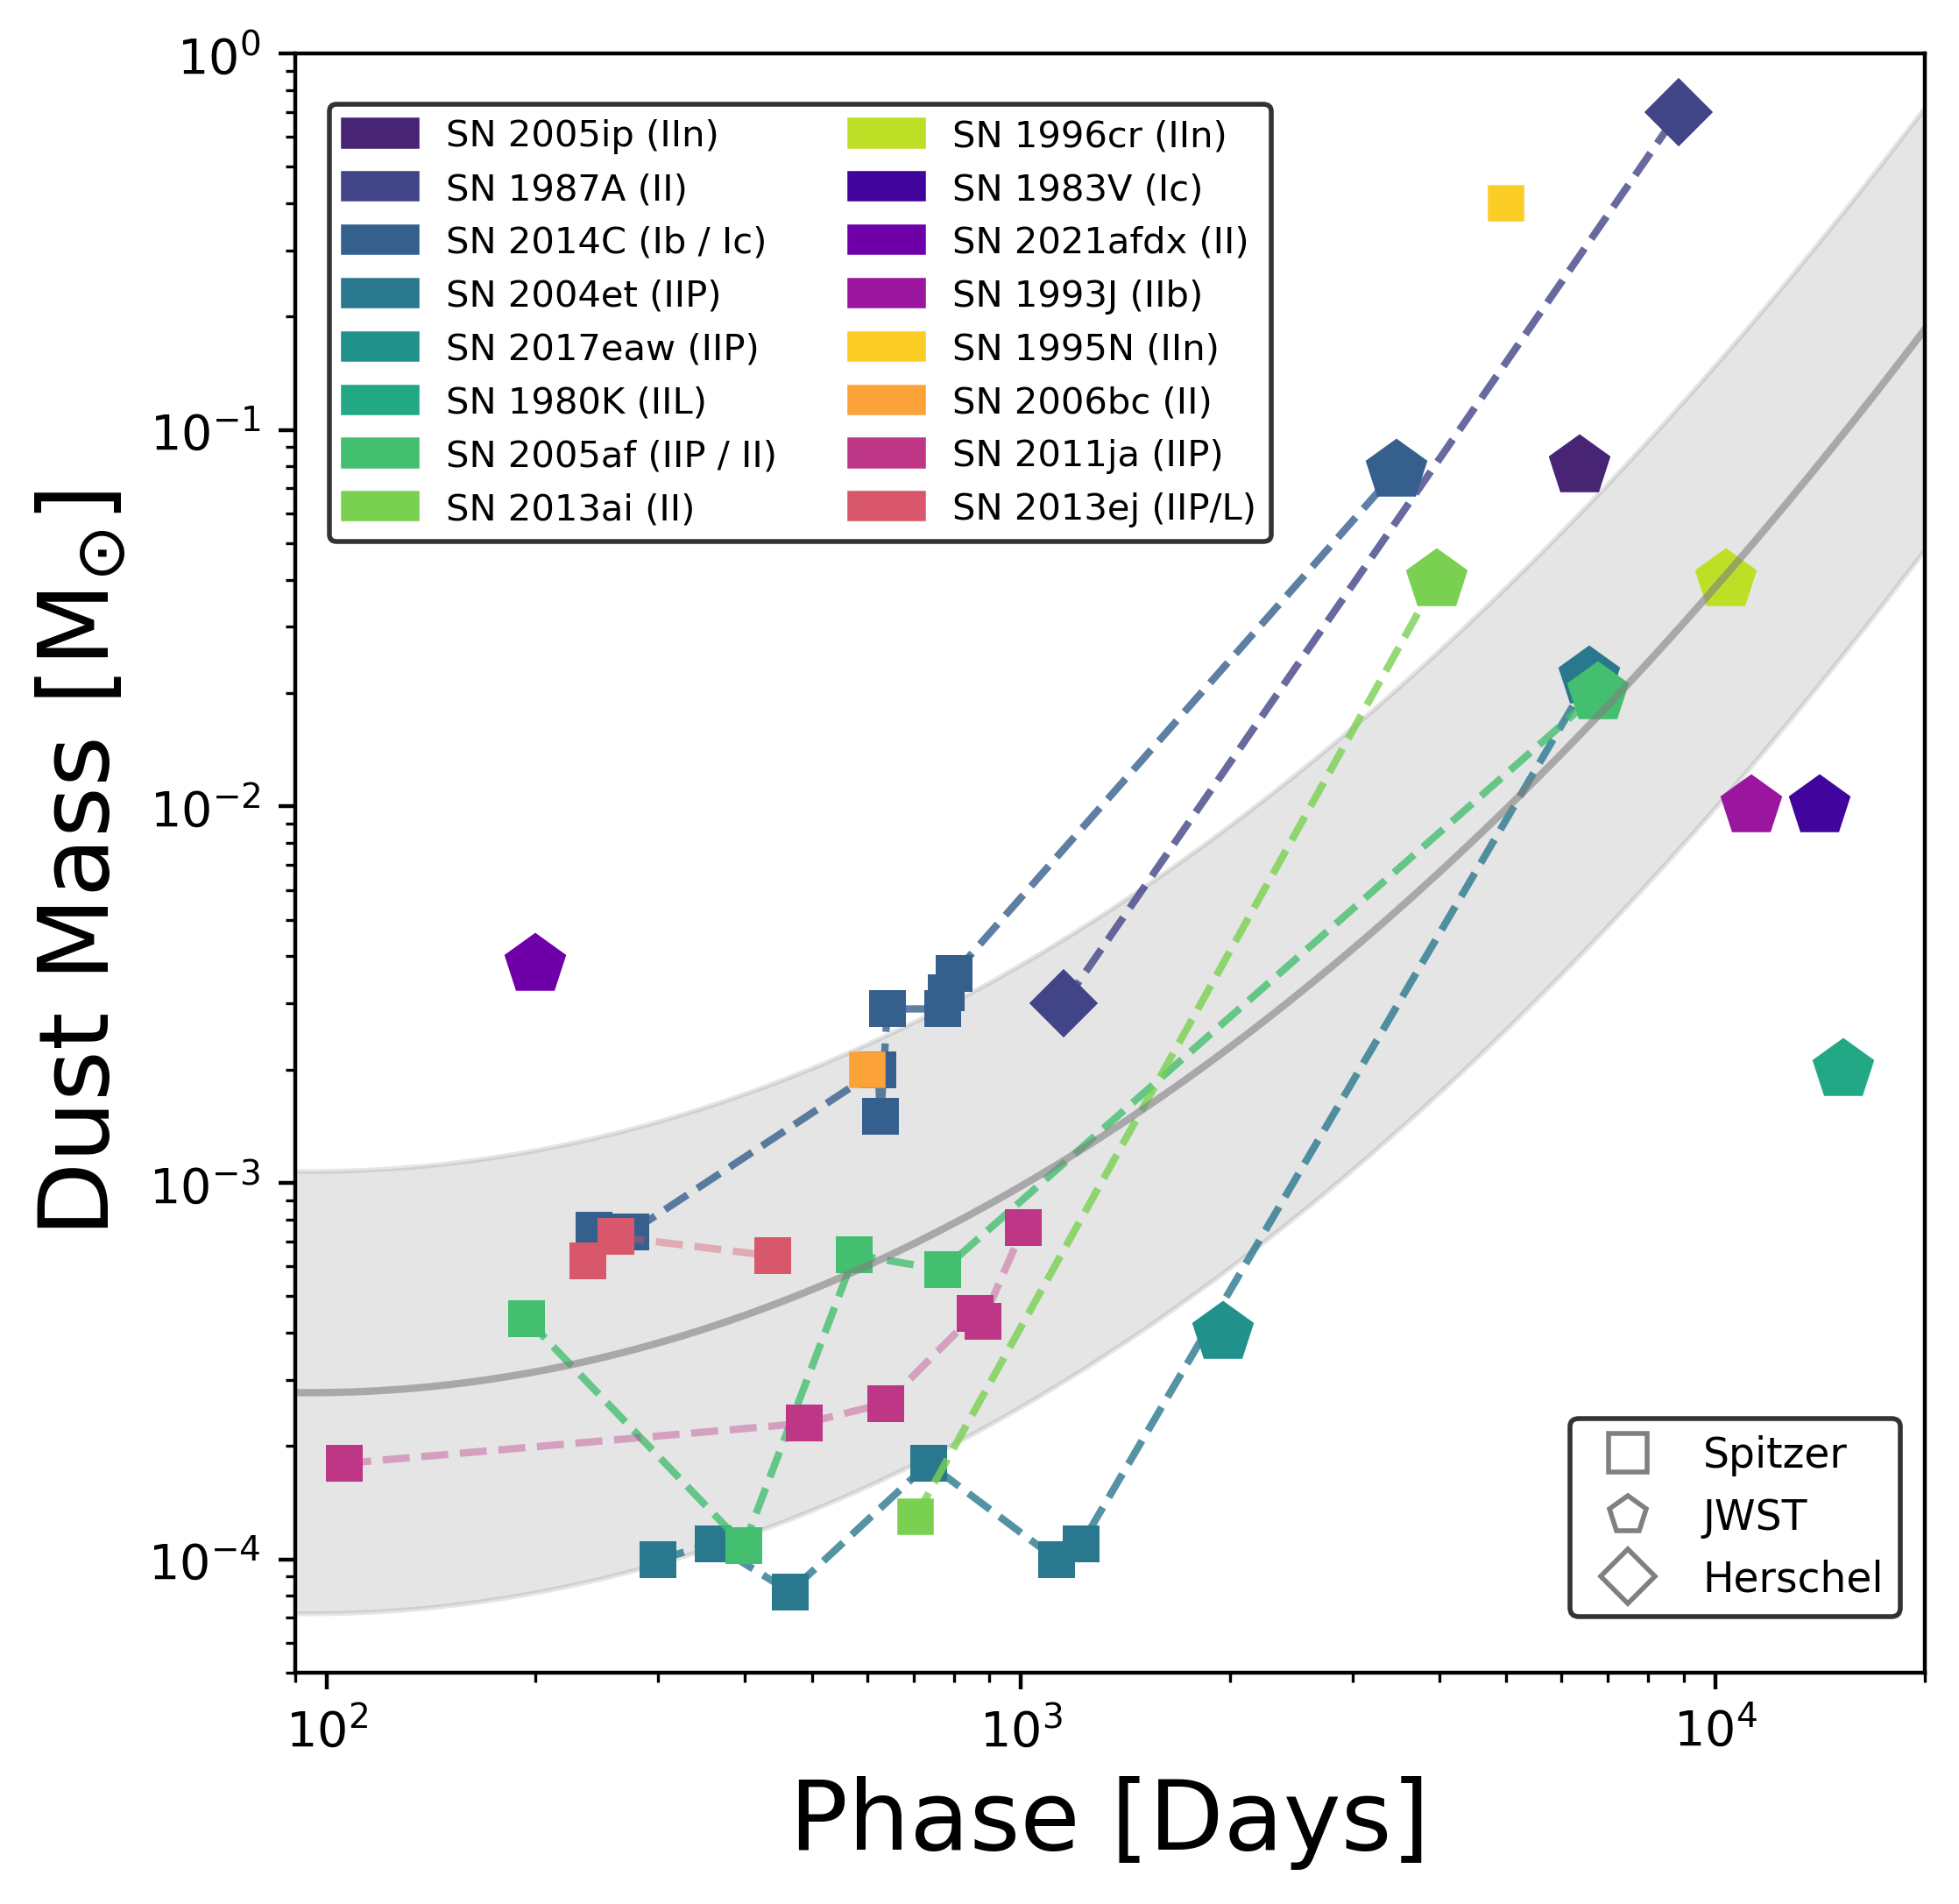

In [3]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.lines as mlines
import numpy as np

plot_spitzer = ["SN 2011ja", "SN 2013ej", "SN 1995N", "SN 2006bc", "SN 1995N"]

# Define telescope markers
telescope_markers = {
    'Spitzer': 's',  
    'JWST': 'p',   
    'Herschel': 'D', 
    # 'VLT/XShooter': 'X', 

}


fig, ax = plt.subplots(dpi=400, figsize=(6,6))

colored_SNe = []
for SN in dust_data.SN.unique():
    data_for_this_sn = dust_data[dust_data['SN'] == SN]
    if data_for_this_sn.telescope.str.contains('JWST').any():
        colored_SNe.append(SN)
    elif data_for_this_sn.telescope.str.contains('Herschel').any():
        colored_SNe.append(SN)
        
colored_SNe.extend(plot_spitzer)
# Get all unique datasets
n = len(colored_SNe)
half = n // 2 + n % 2
# Generate colors
colors_viridis = plt.cm.viridis(np.linspace(0.1, 0.9, half))
colors_plasma = plt.cm.plasma(np.linspace(0.1, 0.9, n - half))
colors = np.vstack((colors_viridis, colors_plasma))
colors = [tuple(c) for c in colors]  # convert to tuples for matplotlib
colors = iter(colors)

sn_color_index = {}

for sn in colored_SNe:
    sn_color_index[sn] = next(colors)
# Store legend patches
patches = []


plotted_data = np.empty((0, 2)) 

# Loop through datasets
for data_set in dust_data.SN.unique():
    sn_data = dust_data[dust_data.SN == data_set]
    
    if not (
        sn_data.telescope.str.contains("JWST").any()
        or sn_data.telescope.str.contains("Herschel").any()
        or data_set in colored_SNe
    ):
        print(f"not plotting {data_set}")
        continue

    sn_data_sorted = sn_data.sort_values(by='epoch')
    
    # Get unique types for label
    sn_types = sn_data_sorted['type'].unique()
    label = ' / '.join(sn_types)
    
    if data_set in colored_SNe:
        color =  sn_color_index[data_set]
    else:
        color = (0.5,0.5,0.5)
    
    if sn_data.telescope.str.contains('JWST').any():
        patches.append(mpatches.Patch(color=color, label=f"{data_set} ({label})"))
    elif sn_data.telescope.str.contains('Herschel').any():
        patches.append(mpatches.Patch(color=color, label=f"{data_set} ({label})"))
    elif set(sn_data.telescope.unique()) == {'Spitzer'}:
        patches.append(mpatches.Patch(color=color, label=f"{data_set} ({label})"))
    elif set(sn_data.telescope.unique()) == {'VLT/XShooter'}:
        patches.append(mpatches.Patch(color=color, label=f"{data_set} ({label})"))

    for telescope in sn_data_sorted['telescope']:
        sn_data_telescope = sn_data[sn_data['telescope'] == telescope]
        marker = telescope_markers.get(telescope, 'o')
        if telescope == 'JWST':
            markersize = 12
            line_alpha = 0.8
        elif telescope == 'Herschel':
            markersize = 9            
            line_alpha = 0.8
        elif telescope == 'VLT/XShooter':
            markersize = 9            
            line_alpha = 0.8
        else:
            markersize = 6.5
            line_alpha = 0.4
            
        ax.plot(
            sn_data_telescope['epoch'].astype(float),
            sn_data_telescope['dust_mass'].astype(float),
            marker=marker,
            color=color,
            linestyle='None',
            markersize=markersize
        )
        
        for i in range(len(sn_data_telescope['epoch'])):
            x = sn_data_telescope['epoch'].iloc[i]
            y = sn_data_telescope['dust_mass'].iloc[i] 
            values = np.array([x,y])       
            plotted_data = np.vstack((plotted_data, values))


    
    ax.plot(
    sn_data_sorted['epoch'].astype(float),
    sn_data_sorted['dust_mass'].astype(float),
    linestyle='--',
    marker = None,
    color=color,
    alpha=line_alpha
    )
    
    
# fitting and plotting a trend line 

x = plotted_data[:,0]
y = plotted_data[:,1]

# Polynomial order
n = 2

# --- Fit polynomial in log–log space ---
logx = np.log10(x)
logy = np.log10(y)
p = np.polyfit(logx, logy, n)
logy_fit = np.polyval(p, logx)

# --- Compute 1σ scatter (standard deviation of residuals) ---
residuals = logy - logy_fit
sigma = np.std(residuals)

# --- Evaluate smooth fit curve ---
logx_fit = np.linspace(np.log(1), np.log(200), 300)
logy_fit = np.polyval(p, logx_fit)

# --- Compute ±1σ bounds in log-space and convert back to linear scale ---
y_fit = 10**logy_fit
y_upper = 10**(logy_fit + sigma)
y_lower = 10**(logy_fit - sigma)
x_fit = 10**logx_fit

plt.plot(x_fit, y_fit, '-', color='grey', label=f'Poly fit (order {n})',alpha = 0.6)
plt.fill_between(x_fit, y_lower, y_upper, color='grey', alpha=0.2, label='±1σ region')




# patches.append(mpatches.Patch(color=color, label=label))
# patches.append(mpatches.Patch(color=color, label=f"{data_set} ({label})"))

    # Add patch for legend
# Axis scales and labels
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel(r'Phase [Days]', fontsize=20)
ax.set_ylabel(r'Dust Mass [$\rm M_{\odot}$]', fontsize=20)

# Legend for telescope markers
legend_handles = [
    mlines.Line2D([], [], color='gray', marker=marker, linestyle='None', 
                  markersize=8, markerfacecolor='none', label=telescope)
    for telescope, marker in telescope_markers.items()
]

# telescopes 
first_legend = ax.legend(handles=legend_handles, loc='upper left', bbox_to_anchor=(0.77, 0.17), prop={'size': 8.5})

first_legend.get_frame().set_edgecolor('black')    
first_legend.get_frame().set_linewidth(1.0)        
first_legend.get_frame().set_facecolor('none')
ax.add_artist(first_legend)


# Legend for supernovae 
leg = ax.legend(handles=patches, loc='upper center', bbox_to_anchor=(0.31, 0.98),
          ncol=2, prop={'size': 7.5}, markerscale=1.5)

frame = leg.get_frame()
frame.set_edgecolor('black')    
frame.set_linewidth(1.0)        
frame.set_facecolor('none')


ax.set_xlim(90,20000)
ax.set_ylim(5e-5,1)

# Save figure
plt.savefig('dust_phase_V2.4.png', bbox_inches='tight', pad_inches=0.3, transparent=False)
plt.show()
